In [81]:
#1 Data loading and preprocessing
"""
Customer Churn Prediction with KNN
Author: Ayhan Demir
Description: Predict whether a telecom customer will churn using KNN
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# Load the Telco Customer Churn dataset
print("Loading Telco customer churn dataset...")
df = pd.read_csv(r'/Users/macbook-air/Desktop/AI consulting/Week1/Day3/WA_Fn-UseC_-Telco-Customer-Churn.csv')  # URL from my folder

print(f"\nDataset type: {type(df)}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Target classes: {df['Churn'].unique().tolist()}")

print("\nFirst few rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nTarget distribution:")
print(df['Churn'].value_counts())
print(f"Churned (Yes): {(df['Churn'] == 'Yes').sum()}")
print(f"Did not churn (No): {(df['Churn'] == 'No').sum()}")

Loading Telco customer churn dataset...

Dataset type: <class 'pandas.DataFrame'>
Number of samples: 7043
Number of columns: 21
Target classes: ['No', 'Yes']

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL     


BASIC STATISTICS
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000

MISSING VALUES
✓ No missing values found!

FEATURE DISTRIBUTIONS
Saved visualization to 'feature_distributions.png'


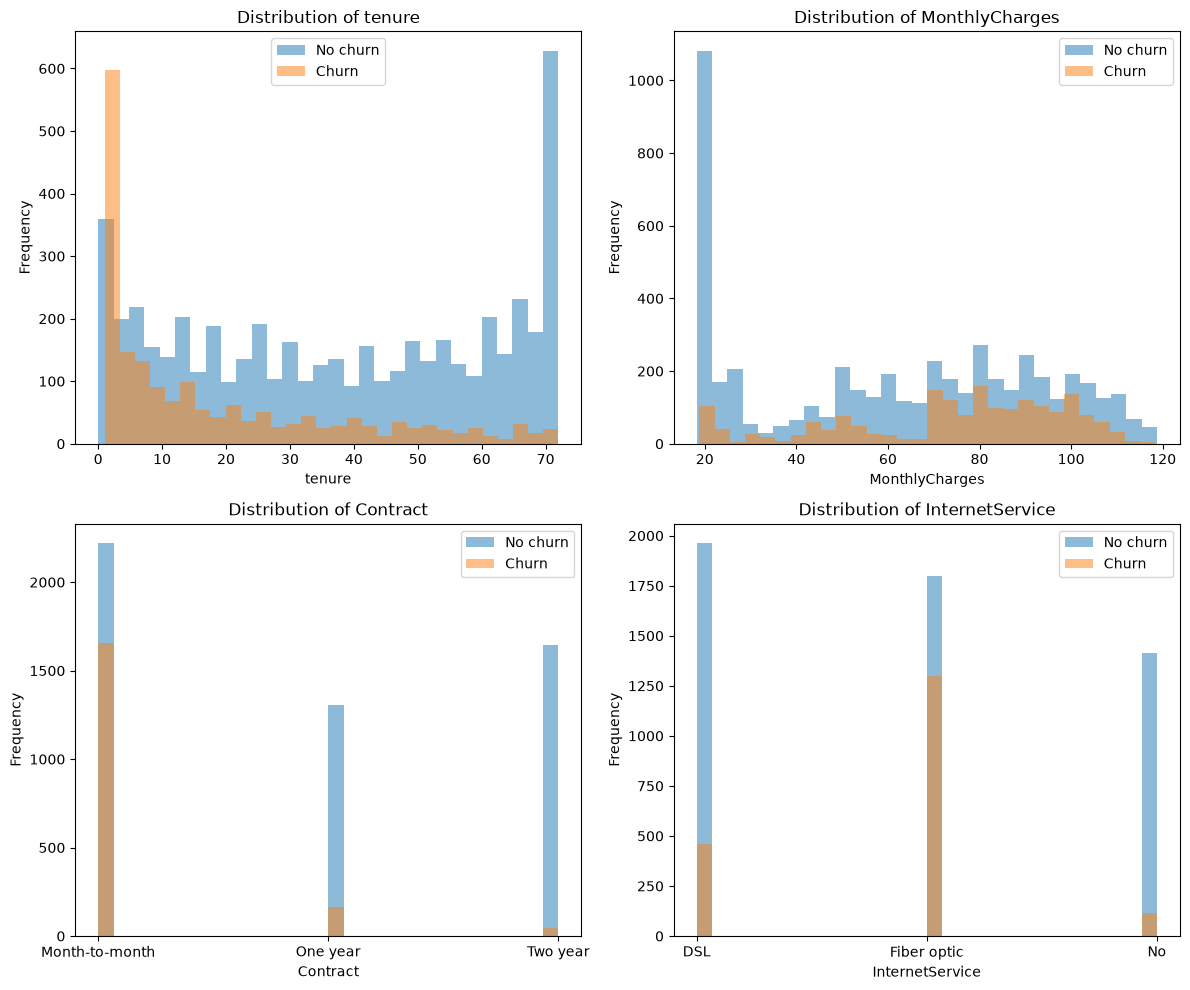

In [82]:
#2 Data Exploration

# Basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df.describe())

# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])

# Visualize feature distributions (select a few key features)
print("\n" + "="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)

# Select a few representative features to visualize
key_features = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService']      #adjusted from previous example
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    axes[idx].hist(df[df['Churn'] == 'No'][feature], alpha=0.5, label='No churn', bins=30)      #adjusted from previous example
    axes[idx].hist(df[df['Churn'] == 'Yes'][feature], alpha=0.5, label='Churn', bins=30)      #adjusted from previous example
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'feature_distributions.png'")
plt.show()

In [83]:
#3 Data Preprocessing

# Handle missing values and TotalCharges is stored as text, blank entries become NaN when converted to numbers - mostly AI support
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Drop the rows with missing values
df = df.dropna()
print(f"Rows after dropping missing values: {df.shape[0]}")

# Select relevant features
# customerID is only an identifier, it does not help predict churn
df = df.drop('customerID', axis=1)

# Convert target to binary: Yes = 1, No = 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separate features and target
X = df.drop('Churn', axis=1)  # All columns except 'Churn'
y = df['Churn']  # Target column

# Convert categorical variables to numeric (one-hot encoding)
X = pd.get_dummies(X, drop_first=True, dtype=int)

print("\n" + "="*50)
print("PREPROCESSED DATA")
print("="*50)
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\nFirst few rows of features:")
print(X.head())

print("\nTarget distribution:")
print(y.value_counts())
print(f"Churned (1): {(y == 1).sum()}")
print(f"Did not churn (0): {(y == 0).sum()}")


MISSING VALUES
Missing values in TotalCharges: 11
Rows after dropping missing values: 7032

PREPROCESSED DATA
Features shape: (7032, 30)
Target shape: (7032,)

First few rows of features:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85            0   
1              0      34           56.95       1889.50            1   
2              0       2           53.85        108.15            1   
3              0      45           42.30       1840.75            1   
4              0       2           70.70        151.65            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0         

In [84]:
#4 Splitting the data

# Split into training and testing sets - 80-20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("\n" + "="*50)
print("DATA SPLIT")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training features: {X_train.shape[1]}")
print(f"Test features: {X_test.shape[1]}")

# Verify class distribution in both sets
print("\nTraining set target distribution:")
print(y_train.value_counts())
print(f"  Did not churn (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Churned (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

print("\nTest set target distribution:")
print(y_test.value_counts())
print(f"  Did not churn (0): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Churned (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")


DATA SPLIT
Training set size: 5625 samples
Test set size: 1407 samples
Training features: 30
Test features: 30

Training set target distribution:
Churn
0    4130
1    1495
Name: count, dtype: int64
  Did not churn (0): 4130 (73.4%)
  Churned (1): 1495 (26.6%)

Test set target distribution:
Churn
0    1033
1     374
Name: count, dtype: int64
  Did not churn (0): 1033 (73.4%)
  Churned (1): 374 (26.6%)


In [85]:
#5 Making predictions - copied from previous example

y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

print(f"\nTraining predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")


Training predictions: 5625
Test predictions: 1407


In [86]:
#6 Evaluating the model and its performance

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)

print("=== Model Performance ===")
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nTest Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

print("\n=== Confusion Matrix ===") #adjusted from previous example
print("                    Predicted")
print("                 No churn  Churn")
print(f"Actual No churn     {test_confusion[0,0]:4d}   {test_confusion[0,1]:4d}")
print(f"       Churn        {test_confusion[1,0]:4d}   {test_confusion[1,1]:4d}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=['No churn', 'Churn']))

=== Model Performance ===

Training Accuracy: 0.8327 (83.27%)
Test Accuracy: 0.7463 (74.63%)

Test Precision: 0.5281
Test Recall: 0.4278

=== Confusion Matrix ===
                    Predicted
                 No churn  Churn
Actual No churn      890    143
       Churn         214    160

=== Classification Report ===
              precision    recall  f1-score   support

    No churn       0.81      0.86      0.83      1033
       Churn       0.53      0.43      0.47       374

    accuracy                           0.75      1407
   macro avg       0.67      0.64      0.65      1407
weighted avg       0.73      0.75      0.74      1407



In [87]:
#7 Training KNN model

# Create KNN classifier and n_neighbors=5 means the model will look at the 5 nearest neighbors to make a prediction
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("KNN classifier trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")

KNN classifier trained successfully!
Number of neighbors (k): 5



EXPERIMENTING WITH DIFFERENT K VALUES
K= 1: Accuracy=0.7093, Precision=0.4545, Recall=0.4679
K= 3: Accuracy=0.7385, Precision=0.5093, Recall=0.4412
K= 5: Accuracy=0.7463, Precision=0.5281, Recall=0.4278
K= 7: Accuracy=0.7662, Precision=0.5768, Recall=0.4519
K= 9: Accuracy=0.7619, Precision=0.5741, Recall=0.4037
K=11: Accuracy=0.7697, Precision=0.6000, Recall=0.4011
K=15: Accuracy=0.7669, Precision=0.5991, Recall=0.3717

Best K value: 11 (Accuracy: 0.7697)

Saved visualization to 'knn_k_comparison.png'


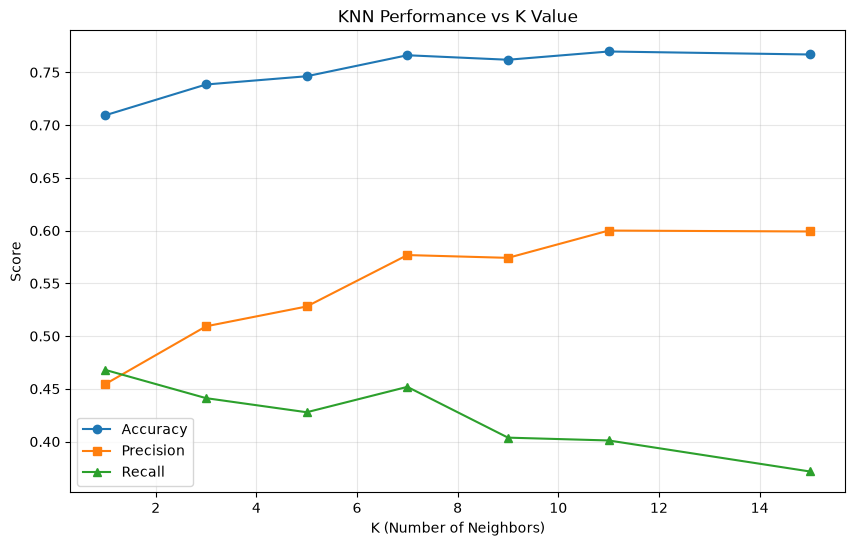

In [88]:
#8 Different K Value Experiments - adjusted from previous example

print("\n" + "="*50)
print("EXPERIMENTING WITH DIFFERENT K VALUES")
print("="*50)

k_values = [1, 3, 5, 7, 9, 11, 15]
results = []

for k in k_values:
    # Create and train model
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    
    # Make predictions
    y_pred_temp = knn_temp.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp)
    
    results.append({
        'K': k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec
    })
    
    print(f"K={k:2d}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")

# Find best K 
results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['Accuracy'].idxmax(), 'K']
print(f"\nBest K value: {best_k} (Accuracy: {results_df['Accuracy'].max():.4f})")


# Visualize results 
plt.figure(figsize=(10, 6))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['K'], results_df['Precision'], marker='s', label='Precision')
plt.plot(results_df['K'], results_df['Recall'], marker='^', label='Recall')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Score')
plt.title('KNN Performance vs K Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('knn_k_comparison.png', dpi=150, bbox_inches='tight')
print("\nSaved visualization to 'knn_k_comparison.png'")
plt.show()

In [89]:
#9 Analysis: which features relate to churn

print("\n" + "="*50)
print("CHURN RATE BY FEATURE")
print("="*50)

# Churn is 0/1, so the mean of each group is its churn rate
key_features = ['Contract', 'InternetService', 'PaymentMethod']

for feature in key_features:
    print(f"\nChurn rate (%) by {feature}:")
    print((df.groupby(feature)['Churn'].mean() * 100).round(1))

# Numeric features: compare the averages of churners and non-churners
print("\nAverage values by churn (0 = stayed, 1 = churned):")
print(df.groupby('Churn')[['tenure', 'MonthlyCharges']].mean().round(1))


CHURN RATE BY FEATURE

Churn rate (%) by Contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

Churn rate (%) by InternetService:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64

Churn rate (%) by PaymentMethod:
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.3
Electronic check             45.3
Mailed check                 19.2
Name: Churn, dtype: float64

Average values by churn (0 = stayed, 1 = churned):
       tenure  MonthlyCharges
Churn                        
0        37.7            61.3
1        18.0            74.4


## Analysis and Recommendations

### What is the model's accuracy?
The first model (K=5) reaches 74.6% accuracy on the test set. 
The chosen model (K=7) reaches 76.6% accuracy, with 57.7% precision and 45.2% recall. It correctly identifies 169 of the 374 churners in the test set and misses 205.
K=11 had the best accuracy but still chose 7 for less depth and avoiding memorizing

### What features seem most important?
Based on the feature distributions and churn rates:
- **Contract type:** 42.7% of month-to-month customers churn, against 11.3% on one-year and 2.8% on two-year contracts.
- **Payment method:** 45.3% of customers paying by electronic check churn, against 15-19% for the other methods.
- **Internet service:** 41.9% of fiber optic customers churn, against 19.0% for DSL.
- **Tenure:** churners have been customers for 18 months on average, against 38 months for those who stayed.
- **Monthly charges:** churners pay more on average (74.4 against 61.3).

### What would I recommend to the company?
- Encourage electronic check customers to switch to automatic payment.
- Investigate why fiber optic customers leave at twice the rate of DSL customers (price, service quality or competition).
- Focus retention on month-to-month customers in their first year, for example with incentives to move to a one-year or two-year contract.
- Use the model as a first screen to prioritise retention calls.

### What are the limitations of the model?
- **Low recall:** the model misses more than half of the customers who churn.
- **Class imbalance:** only 26.6% of customers churn, which pulls predictions toward "no churn".
- **Small gain over a simple baseline:** predicting "no churn" for everyone already gives 73.4% accuracy.
- **Correlation, not cause:** the feature patterns show who churns, not why, so the recommendations should be tested before a full rollout.